<a href="https://colab.research.google.com/github/kishan4935/Predict-Calorie-Expenditure/blob/main/Predict_Calorie_Expenditure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
submission = pd.read_csv("/content/sample_submission.csv")

In [14]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\nTrain Info:")
train.info()
print("\nTest Info:")
test.info()
print("\nTrain Describe:")
train.describe()

Train Shape: (750000, 9)
Test Shape: (250000, 8)

Train Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB

Test Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age     

,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


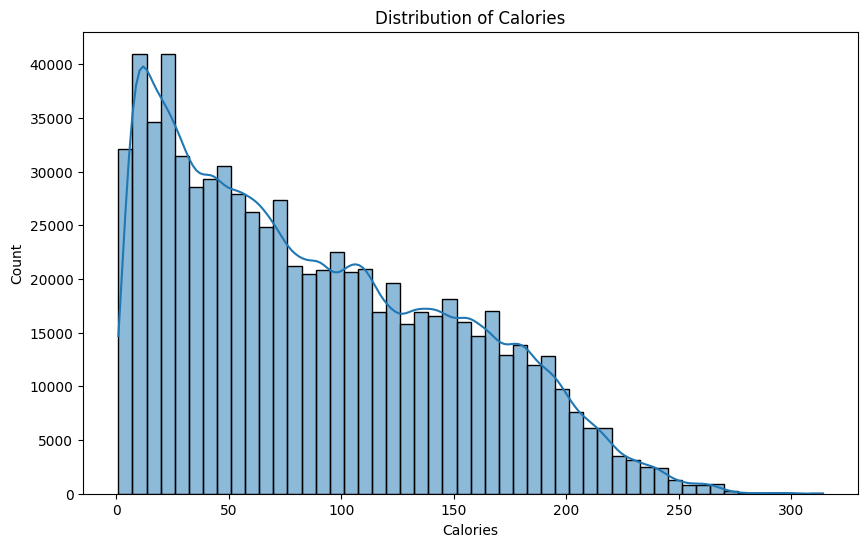

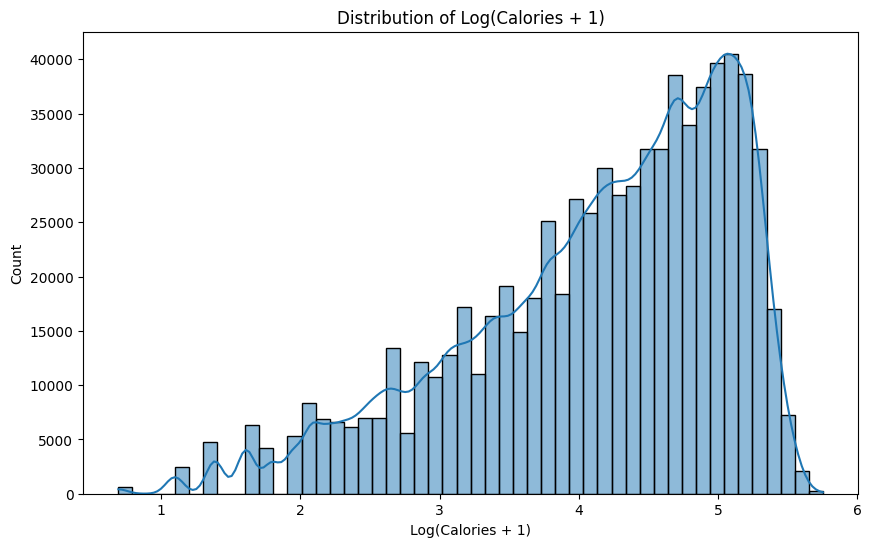

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(train['Calories'], bins=50, kde=True)
plt.title('Distribution of Calories')
plt.xlabel('Calories')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(train['Calories']), bins=50, kde=True)
plt.title('Distribution of Log(Calories + 1)')
plt.xlabel('Log(Calories + 1)')
plt.ylabel('Count')
plt.show()

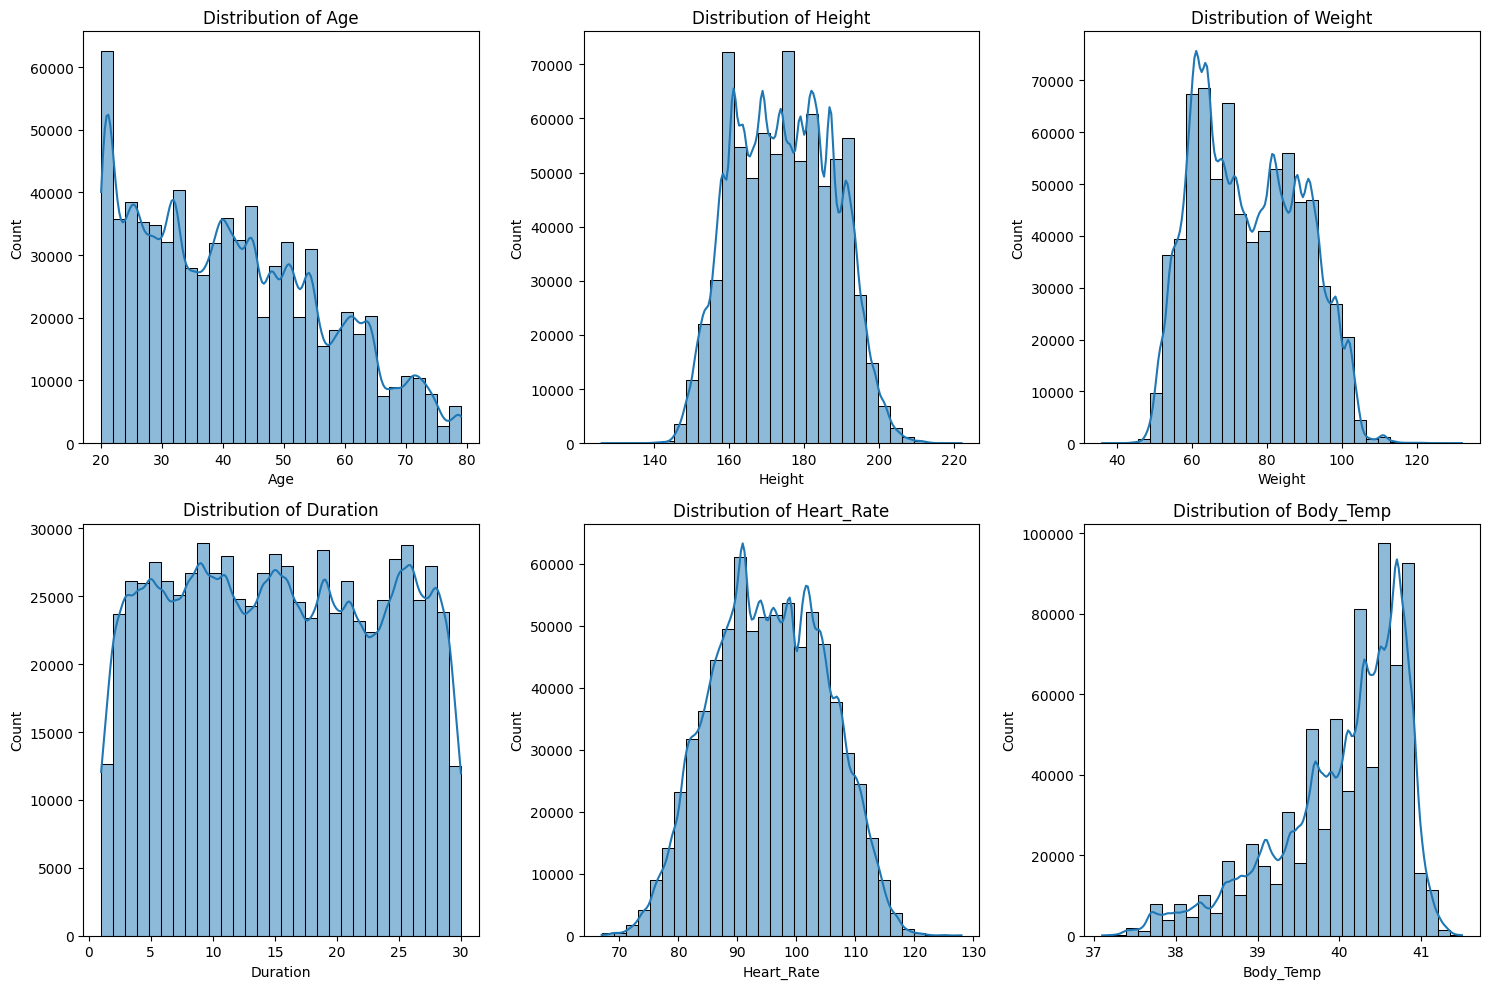


Sex Distribution:
Sex
female    375721
male      374279
Name: count, dtype: int64


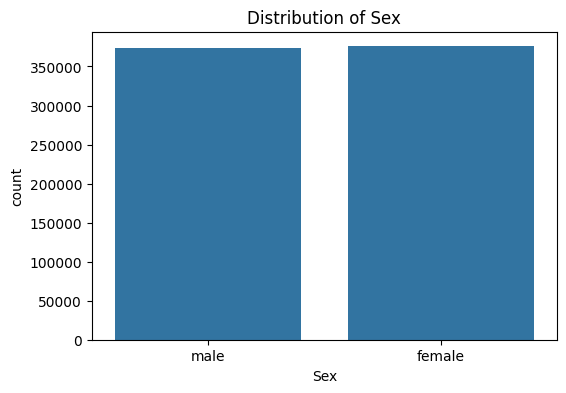

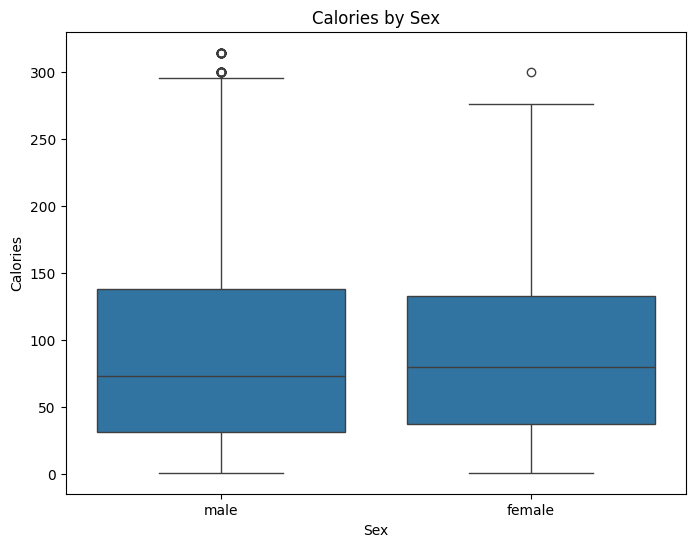

In [16]:
numerical_features = ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train[feature], bins=30, kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

print("\nSex Distribution:")
print(train['Sex'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='Sex', data=train)
plt.title('Distribution of Sex')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Sex', y='Calories', data=train)
plt.title('Calories by Sex')
plt.show()

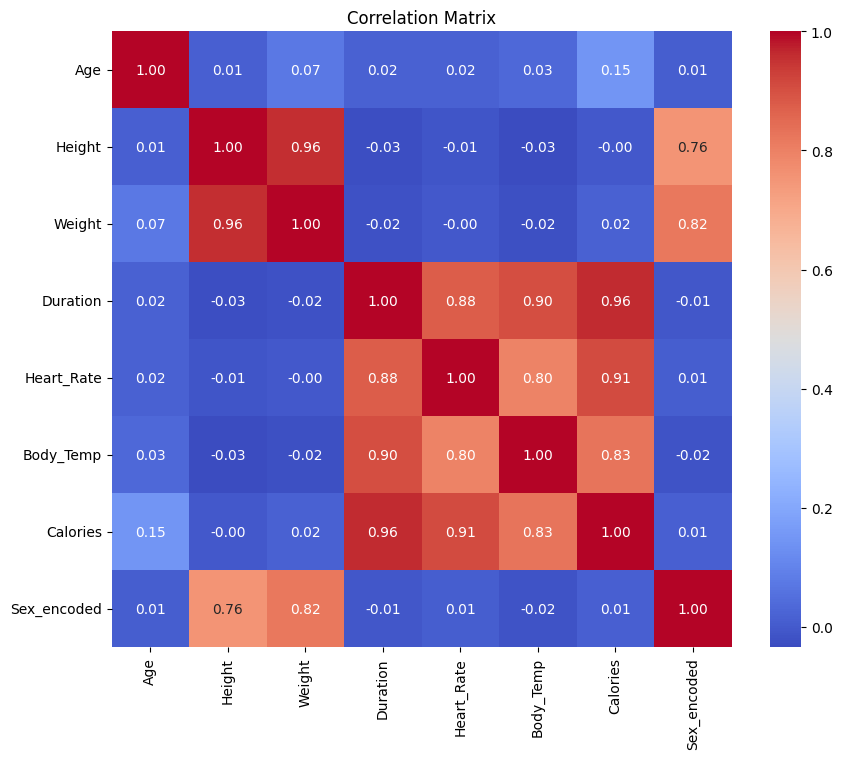

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['Sex_encoded'] = le.fit_transform(train['Sex'])

corr = train[numerical_features + ['Calories', 'Sex_encoded']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [18]:
train = train.drop('Sex_encoded', axis=1)

def add_feature_cross_terms(df, numerical_features):
    df_new = df.copy()
    for i in range(len(numerical_features)):
        for j in range(i + 1, len(numerical_features)):
            feature1 = numerical_features[i]
            feature2 = numerical_features[j]
            cross_term_name = f"{feature1}_x_{feature2}"
            df_new[cross_term_name] = df_new[feature1] * df_new[feature2]
    return df_new

train = add_feature_cross_terms(train, numerical_features)
test = add_feature_cross_terms(test, numerical_features)

train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

train['Sex'] = train['Sex'].astype('category')
test['Sex'] = test['Sex'].astype('category')

X = train.drop(columns=['id', 'Calories'])
y = np.log1p(train['Calories'])
X_test = test.drop(columns=['id'])

FEATURES = X.columns.tolist()

In [20]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 4.8 MB/s eta 0:00:00


In [21]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_log_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

FOLDS = 5
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=42)
models = {
    'CatBoost': CatBoostRegressor(verbose=100, random_seed=42, cat_features=['Sex'], early_stopping_rounds=100),
    'XGBoost': XGBRegressor(max_depth=10, colsample_bytree=0.7, subsample=0.9, n_estimators=2000, learning_rate=0.02,
                            gamma=0.01, max_delta_step=2, early_stopping_rounds=100, eval_metric='rmse',
                            enable_categorical=True, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=2000, learning_rate=0.02, max_depth=10, colsample_bytree=0.7,
                              subsample=0.9, random_state=42, verbose=-1)
}

results = {name: {'oof': np.zeros(len(train)), 'pred': np.zeros(len(test)), 'rmsle': []} for name in models}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    for i, (train_idx, valid_idx) in enumerate(kf.split(X, y)):
        print(f"\nFold {i+1}")
        x_train, y_train = X.iloc[train_idx], y[train_idx]
        x_valid, y_valid = X.iloc[valid_idx], y[valid_idx]
        x_test = X_test.copy()

        start = time.time()

        if name == 'XGBoost':
            model.fit(x_train, y_train, eval_set=[(x_valid, y_valid)], verbose=100)
        elif name == 'CatBoost':
            model.fit(x_train, y_train, eval_set=(x_valid, y_valid))
        else:
            model.fit(x_train, y_train)

        oof_pred = model.predict(x_valid)
        test_pred = model.predict(x_test)

        results[name]['oof'][valid_idx] = oof_pred
        results[name]['pred'] += test_pred / FOLDS

        rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_valid), np.expm1(oof_pred)))
        results[name]['rmsle'].append(rmsle)

        print(f"Fold {i+1} RMSLE: {rmsle:.4f}")
        print(f"Training time: {time.time() - start:.1f} sec")

print("\n=== Model Comparison ===")
for name in models:
    mean_rmsle = np.mean(results[name]['rmsle'])
    std_rmsle = np.std(results[name]['rmsle'])
    print(f"{name} - Mean RMSLE: {mean_rmsle:.4f} ± {std_rmsle:.4f}")


=== Training CatBoost ===

Fold 1
Learning rate set to 0.139016
0:	learn: 0.8386687	test: 0.8379187	best: 0.8379187 (0)	total: 270ms	remaining: 4m 29s
100:	learn: 0.0635160	test: 0.0640850	best: 0.0640850 (100)	total: 12s	remaining: 1m 46s
200:	learn: 0.0606372	test: 0.0618655	best: 0.0618655 (200)	total: 23.9s	remaining: 1m 35s
300:	learn: 0.0593793	test: 0.0611201	best: 0.0611201 (300)	total: 35.9s	remaining: 1m 23s
400:	learn: 0.0585508	test: 0.0606770	best: 0.0606769 (399)	total: 47.9s	remaining: 1m 11s
500:	learn: 0.0579410	test: 0.0604149	best: 0.0604149 (500)	total: 58.7s	remaining: 58.4s
600:	learn: 0.0574428	test: 0.0602201	best: 0.0602201 (600)	total: 1m 9s	remaining: 46.3s
700:	learn: 0.0570004	test: 0.0601133	best: 0.0601118 (699)	total: 1m 21s	remaining: 34.8s
800:	learn: 0.0565986	test: 0.0600612	best: 0.0600568 (786)	total: 1m 33s	remaining: 23.1s
900:	learn: 0.0562683	test: 0.0600020	best: 0.0600020 (900)	total: 1m 44s	remaining: 11.5s
999:	learn: 0.0559452	test: 0.059

In [22]:
best_model_name = min(results, key=lambda x: np.mean(results[x]['rmsle']))
best_model = models[best_model_name]

if best_model_name == 'CatBoost':
    feature_importance = best_model.get_feature_importance()
    feature_names = X.columns
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
    importance_df = importance_df.sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title(f'{best_model_name} Feature Importance')
    plt.show()

y_preds = np.expm1(results[best_model_name]['pred'])

y_preds = np.clip(y_preds, 1, 314)

submission['Calories'] = y_preds
submission.to_csv('submission.csv', index=False)

print("\nSubmission Head:")
print(submission.head())

print(f"\nPredict Mean: {y_preds.mean():.2f}")
print(f"Predict Median: {np.median(y_preds):.2f}")


Submission Head:
       id    Calories
0  750000   27.428708
1  750001  107.836805
2  750002   88.006732
3  750003  126.202266
4  750004   75.850591

Predict Mean: 88.16
Predict Median: 76.43
